<h3 align=center>Статистика по выборке, полученной с данных API Московской биржи</h3>

Цель этого проекта - продемонстрировать знания в статистике. Для этого получу данные по свечам акции Сбербанка, используя API Московской 
биржи. Эти данные будут моей выборкой из случайной величины.

<h4 align=center>Получение данных с API Московской биржи по акции Сбербанк</h4>

Использую готовый скрипт из [проекта по парсингу Московской биржи](https://github.com/DmitriyZubkov41/moex/blob/main/README.md), но 
оставлю из него только получение минуток.

In [2]:
import pandas as pd
import requests
from datetime import timedelta, date


def get_all_candles(from_date, till_date, interval, ticker='SBER'):
    """
       Получить все свечи с количеством более 500. Возвращает в виде списка.
    """
    all_candles = []
    start = 0
    
    while True:
        url = f'http://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'
        params = {
            'from': from_date,
            'till': till_date,
            'interval': interval,
            'start': start
        }
        
        response = requests.get(url, params=params)
        data = response.json()
                
        candles = data['candles']['data']
        if not candles:
            break
            
        all_candles.extend(candles)
        #print(f"Получено {len(candles)} свечей, всего {len(all_candles)}")
        
        # Если получено меньше 500, значит это последняя страница
        if len(candles) < 500:
            break
            
        start += 500  # Переходим к следующей странице
    
    return all_candles


def main(from_date=None, till_date=None, ticker='SBER'):
    # Преобразуем строки from_date и till_date в datetime.date 
    if isinstance(from_date, str):
        from_date = datetime.strptime(from_date, '%d.%m.%Y').date()
    
    if isinstance(till_date, str):
        till_date = datetime.strptime(till_date, '%d.%m.%Y').date()
    
    # Меняю значения для аргументов, равных None на значения по умолчанию
    if from_date is None:
        # Для from_date это будет 7 дней назад
        from_date = date.today() - timedelta(days=7)
    if till_date is None:
        till_date = date.today()

    
    all_candles = get_all_candles(from_date=from_date, till_date=till_date, interval=1)
    #print("Считали all_candles ")
    
        
    df = pd.DataFrame(all_candles, columns=['open', 'close', 'high', 'low', 'value', 'volume', 'begin', 'end'])
    df['begin'] = pd.to_datetime(df['begin'], format='%Y-%m-%d %H:%M:%S')
    df['date'] = df['begin'].dt.strftime('%Y%m%d')
    df['time'] = df['begin'].dt.strftime('%H%M')
    
    df = df[['date', 'time', 'open', 'high', 'low', 'close', 'volume']]

    return df
    

df = main()

Теперь нарисуем эти свечки, посмотрим, что скачали.

/home/dmitriy/.local/lib/python3.8/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


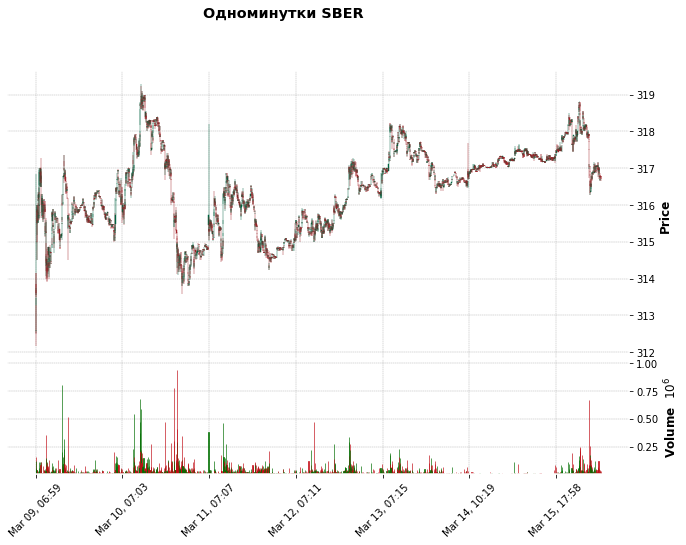

,open,high,low,close,volume
Date,,,,,
2026-03-09 06:59:00,314.00,314.00,314.00,314.00,25182
2026-03-09 07:00:00,314.00,314.14,313.62,313.65,48702
2026-03-09 07:01:00,313.65,313.84,313.62,313.62,16999
2026-03-09 07:02:00,313.77,314.14,313.50,313.55,29140
2026-03-09 07:03:00,313.55,313.73,313.55,313.73,25317
...,...,...,...,...,...
2026-03-16 14:28:00,316.80,316.80,316.76,316.76,17284
2026-03-16 14:29:00,316.79,316.79,316.72,316.78,11066
2026-03-16 14:30:00,316.78,316.79,316.71,316.78,3479


In [3]:
import mplfinance as mpf

def paint_candles(df, title='Одноминутки SBER'):
    """
    Отрисовка свечей с помощью mplfinance
    """
    # Подготовка данных в формате для mplfinance
    df_plot = df.copy()
    df_plot.set_index(pd.to_datetime(df['date'] + df['time'], format='%Y%m%d%H%M'), inplace=True)
    df_plot.index.name = 'Date'
    
    # Выбираем нужные колонки
    df_plot = df_plot[['open', 'high', 'low', 'close', 'volume']]
    
    # Создаем график
    mpf.plot(df_plot, 
             type='candle',
             style='charles',
             title=title,
             ylabel='Price',
             volume=True,
             figsize=(12, 8))
    
    return df_plot

paint_candles(df)

Ничего не видно. Для проверки данных лучше записать в файл .csv и в нём уже проверять, что скачали.

In [4]:
df.to_csv('1min.csv', index=False)

<h4 align=center>Статистика</h4>
Будем считать, что цена закрытия - это случайная величина и столбец close из df будет являться выборкой из случайной величины.

Глядя на свечной график можно предположить, что среднее этой выборки равно 316 и почему-то уверен, что распределение выборки является 
нормальным.

Для описания выборки существуют различные показатели, для расчета которых в Python существуют различные методы, но проще всего 
использовать метод describe() , который разом рассчитает кучу всяких статистических показателей.

In [5]:
df['close'].describe()

count    6516.000000
mean      316.430588
std         1.070127
min       312.580000
25%       315.590000
50%       316.550000
75%       317.250000
max       319.140000
Name: close, dtype: float64

Видим размер выборки, среднее, стандартное отклонение, квартили.

Проведём тест на проверку выборки на нормальность. Есть разные тесты, но проведем самый простой - тест Колмогорова-Смирнова.

In [7]:
def test_kolmogorov_smirnov(df):
    """
    Тест Колмогорова-Смирнова служит для ответа на вопрос, 
    можно ли считать выборку нормальным распределением c математическим ожиданием mu и стандартным отклонением sigma
    """

    from scipy.stats import kstest

    data = df['close']
    
    # Оцениваем среднее и стандартное отклонение нормального распределения по выборке
    mu, sigma = data.mean(), data.std()
    
    statistic, p_value = kstest(data, 'norm', args=(mu, sigma))
    
    print(f"Среднее: {mu:.2f}, Std: {sigma:.2f}")
    print(f"Статистика теста: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    return statistic, p_value

test_kolmogorov_smirnov(df)

Среднее: 316.43, Std: 1.07
Статистика теста: 0.0669
P-value: 0.0000


(0.06689413085300733, 8.530515096955971e-26)

Неожиданно получил p-value равным 0. Захотелось посмотреть на распределение этой выборки.

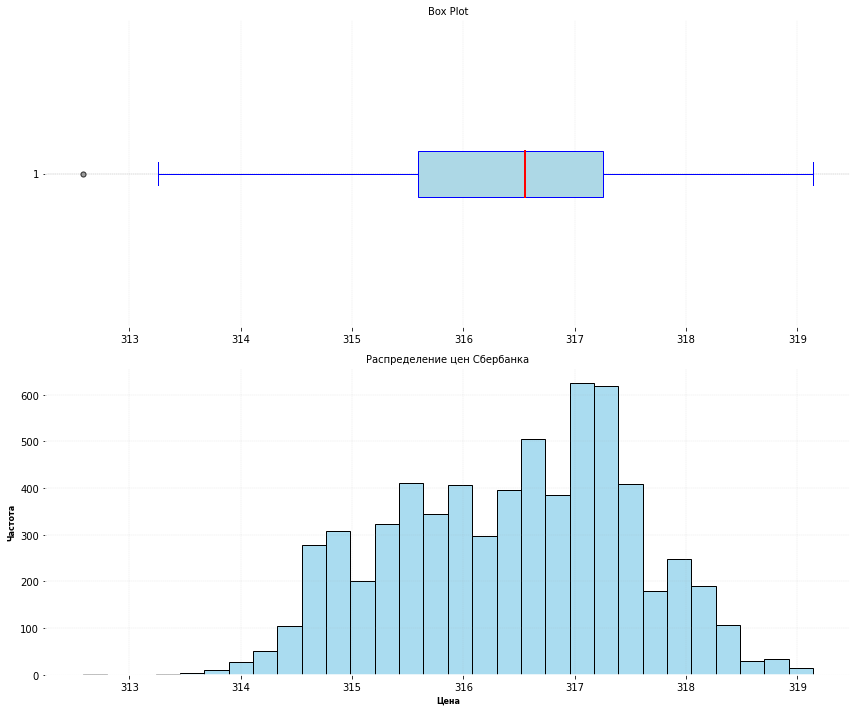

In [8]:
def plot_distribution(df):
    """
    Базовый график распределения цен
    """

    import matplotlib.pyplot as plt
    import seaborn as sns
    
    data = df['close']
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # 1. Box plot на верхнем графике (axes[0])
    box = axes[0].boxplot(data, vert=False, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='blue'),
                         whiskerprops=dict(color='blue'),
                         capprops=dict(color='blue'),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='gray', 
                                       markersize=5, alpha=0.5))
    
    # Добавляем заголовок и подписи для боксплота
    axes[0].set_title('Box Plot', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='x')

      
    # 2. Гистограмма на нижнем графике (axes[1])
    sns.histplot(data, kde=False, bins=30, color='skyblue', edgecolor='black', alpha=0.7, ax=axes[1])
    
    # Добавляем заголовок и подписи для гистограммы
    axes[1].set_title('Распределение цен Сбербанка', fontsize=10)
    axes[1].set_xlabel('Цена', fontsize=8)
    axes[1].set_ylabel('Частота', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_distribution(df)

На box plot видно слева выброс. Для выборок с выбросами рекомендуется проводить другой тест на соответствие нормальному распределению: тест Колмогорова-Смирнова с поправкой Лиллиефорса:

In [9]:
def test_lilliefors(df):
    """
    Тест Колмогорова-Смирнова с поправкой Лиллиефорса 
    """

    from statsmodels.stats.diagnostic import lilliefors

    data = df['close']
    statistic, p_value = lilliefors(data)
    print(f"Статистика теста: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

test_lilliefors(df)

Статистика теста: 0.0669
P-value: 0.0010


Не ноль, но все равно намного меньше обычного уровня значимости в 5 %. 
Распределение однозначно не является нормальным.
Можно ли по полученной выборке проводить тесты, проверять гипотезу?
Одновыборочный t-тест можно, для него выборка не обязательно должна быть нормальным распределением.

Как проводить одновыборочный t-тест<br>
При проведении одновыборочного t-теста выдвигают гипотезу, что среднее популяции равно какому-то значению, скажем mu равно 316. 
Это нулевая гипотеза. Далее вычисляем среднее , стандартное отклонение нашей выборки. Зная размер выборки и отклонение, вычисляем по 
формулам стандартную ошибку, t-оценку. Степени свободы для t-теста - это размер выборки минус 1. Смотрим по таблице наш p-value . 
Это вероятность при верности нулевой гипотезы получить mu, равное 316. Если эта вероятность меньше заранее выбранного уровня значимости 
(обычно 5 %), то считаем, что такая маленькая вероятность получена из-за того, что неверна нулевая гипотеза. То есть отвергаем нулевую 
гипотезу. На этом закончу мои расчёты.

Итог<br>
Я закончил несколько курсов по статистике, но сказать, что мне всё в ней понятно, не могу. По сравнению с тем, что изучал (excel, sql,
программирование), статистика намного сложнее.